In [1]:
import pandas as pd
import json

idx = "00"
base_data = json.load(open("data/streamlit/deepseek_llama_8b/gpqa/base_data.json"))

In [2]:
def load_data(idx: str, file_template: str = "data/streamlit/deepseek_llama_8b/gpqa/{idx}.csv") -> pd.DataFrame:
    """Load CSV data for a given index."""
    df = pd.read_csv(file_template.format(idx=idx))
    return df

# drop the first column
df = load_data(idx)
df = df.drop(df.columns[0], axis=1)
df.head()

,t,outcome,num_rollouts,outcome_probability,prefix,sample_rollout
0,36,A,3,0.15,"Okay, so I've got this question about Klinefel...",Let me start by reading the question carefull...
1,36,B,17,0.85,"Okay, so I've got this question about Klinefel...","Alright, let's start by remembering what I kn..."
2,43,A,4,0.20,"Okay, so I've got this question about Klinefel...",The question is about the molecular mechanism ...
3,43,B,16,0.80,"Okay, so I've got this question about Klinefel...",The question is asking about the molecular mec...
4,72,A,3,0.15,"Okay, so I've got this question about Klinefel...","Wait, or is it the other way around? Wait no,..."


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Outcome Probability Distribution Over Time'}, xlabel='Timestep', ylabel='Outcome Probability'>)

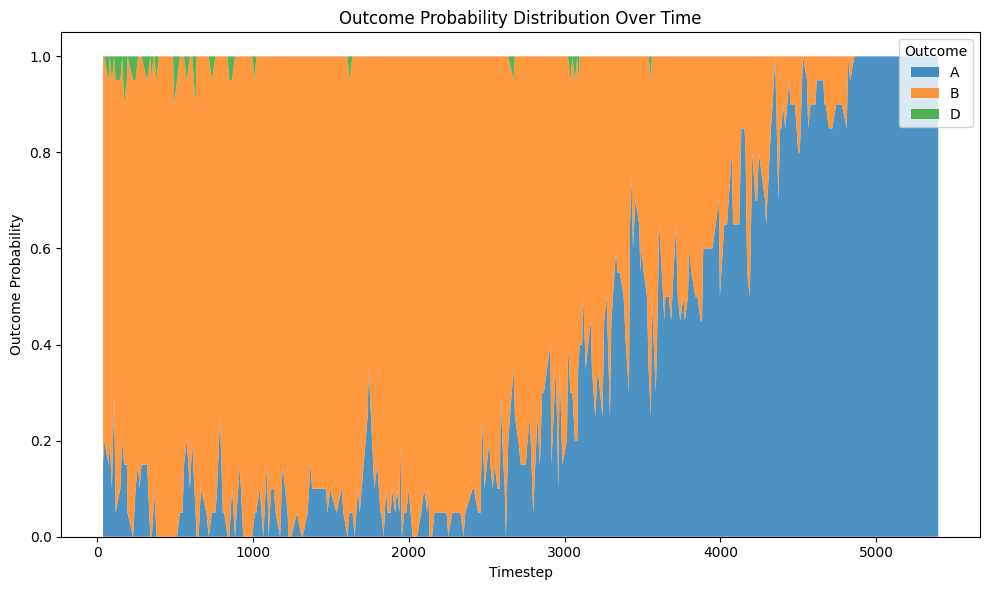

In [3]:
from utils.plotting import plot_outcome_probability

plot_outcome_probability(df)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Entropy of Outcome Probability Distribution Over Time'}, xlabel='Timestep', ylabel='Entropy'>)

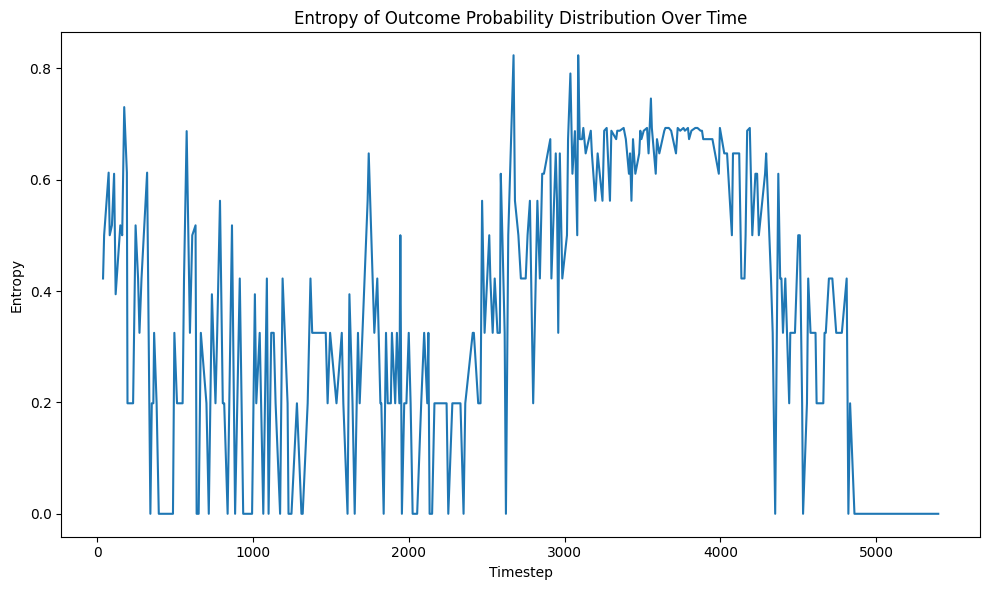

In [4]:
from utils.plotting import plot_entropy

plot_entropy(df)

In [201]:
from typing import Tuple, Optional

def get_final_convergence(df: pd.DataFrame) -> Optional[Tuple[int, str]]:
    """
    Find the timestep when an outcome reaches probability 1.0 and stays there until the end.
    
    Returns:
        (timestep, outcome) if found, None otherwise
    """
    max_t = df['t'].max()
    
    # Check if there's an outcome with probability 1.0 at the final timestep
    final_rows = df[df['t'] == max_t]
    final_locked = final_rows[final_rows['outcome_probability'] == 1.0]
    
    if final_locked.empty:
        return None  # No convergence at the end
    
    # Get the outcome that's locked at the end
    final_outcome = final_locked['outcome'].iloc[0]
    
    # Now find the earliest timestep where this outcome became 1.0 and stayed 1.0
    # Filter for this outcome only
    outcome_df = df[df['outcome'] == final_outcome].sort_values('t')
    
    # Find the earliest timestep from which probability stays 1.0
    # Work backwards from the end to find where it first became 1.0
    timesteps = outcome_df['t'].values
    probs = outcome_df['outcome_probability'].values
    
    # Find the last index where probability is not 1.0
    convergence_start_idx = 0
    for i in range(len(probs) - 1, -1, -1):
        if probs[i] != 1.0:
            convergence_start_idx = i + 1
            break
    
    if convergence_start_idx >= len(timesteps):
        return None  # Edge case: never converged
    
    convergence_t = timesteps[convergence_start_idx]
    
    return int(convergence_t), final_outcome


def get_convergence_for_index(idx: str, file_template: str = "data/streamlit/deepseek_llama_8b/gpqa/{idx}.csv") -> Optional[Tuple[int, str]]:
    """
    Load data for index and return the final convergence timestep and outcome.
    """
    df = load_data(idx, file_template)
    return get_final_convergence(df)

get_convergence_for_index(idx)

(7255, 'C')

In [202]:
def string_match(correct_answer, all_answers, all_letters = ["A", "B", "C", "D"]):
    """Return the index of the answer that matches the correct answer, or -1 if no match is found."""
    for i, answer in enumerate(all_answers):
        if correct_answer == answer:
            return all_letters[i]
    return -1

print("Ground Truth Correct Answer:", string_match(base_data[int(idx)]["correct_answer"], base_data[int(idx)]["all_answers"], base_data[int(idx)]["all_letters"]))
print("Model's Base Prediction:", base_data[int(idx)]["clean_answer"])

Ground Truth Correct Answer: D
Model's Base Prediction: C


In [203]:
from transformers import AutoTokenizer

def find_token_index(tokenizer, token_to_find, token_ids):
    for i,tok in enumerate(tokenizer.convert_ids_to_tokens(token_ids)):
        if token_to_find in tok:
            return i
    return -1


tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")
idxs = [str(i).zfill(2) for i in range(0, 28)]
stats = {}

for i in idxs:
    entry = {}
    df = load_data(i)
    converged_timestep, converged_outcome = get_convergence_for_index(i)
    entry["converged_outcome"] = converged_outcome
    entry["converged_timestep"] = converged_timestep
    entry["base_outcome"] = base_data[int(i)]["clean_answer"]
    entry["correct_outcome"] = base_data[int(i)]["correct_letter"]
    entry["output_length"] = len(base_data[int(i)]["output_token_ids"])
    entry["think_finish_idx"] = find_token_index(tokenizer, "</think>", base_data[int(i)]["output_token_ids"])
    entry["is_correct"] = entry["converged_outcome"] == entry["correct_outcome"]
    stats[i] = entry
    del df

stats = pd.DataFrame(stats)
stats = stats.T
stats

,converged_outcome,converged_timestep,base_outcome,correct_outcome,output_length,think_finish_idx,is_correct
00,A,4861,A,B,5404,4861,False
01,C,7255,C,D,7267,6846,False
02,C,5789,C,D,6612,5879,False
03,A,3289,A,B,3815,3337,False
04,D,4905,D,B,5165,4760,False
05,A,7596,A,D,8288,7670,False
06,A,4150,A,A,4580,4176,True
07,D,6663,D,A,7624,6902,False
08,B,924,B,D,1525,1133,False
09,A,411,A,A,773,505,True


In [204]:
(stats["converged_outcome"] == stats["base_outcome"]).mean()

1.0

In [205]:
def accuracy(base_outcomes, correct_outcomes):
    return sum(1 for i in range(len(base_outcomes)) if base_outcomes[i] == correct_outcomes[i]) / len(base_outcomes)

accuracy(stats["base_outcome"].values, stats["correct_outcome"].values)

0.5357142857142857

In [206]:
dist_from_think_end = stats["think_finish_idx"] - stats["converged_timestep"]
dist_from_output_end = stats["output_length"] - stats["converged_timestep"]

idxs = stats.index[dist_from_think_end > 300].tolist()
len(idxs)

10

In [207]:
dists = pd.DataFrame({
    "from_think_end": dist_from_think_end.values,
    "from_output_end": dist_from_output_end.values,
    "is_correct": stats["is_correct"].values,
})
dist = 200
print(len(dists[(dists["from_think_end"] > dist)]))
dists[(dists["from_think_end"] > dist)]

13


,from_think_end,from_output_end,is_correct
7,239,961,False
8,209,601,False
11,683,1045,True
13,2805,3323,True
16,654,947,True
17,322,721,True
18,1606,2903,True
20,522,1091,True
21,1008,1657,True
23,799,1519,True


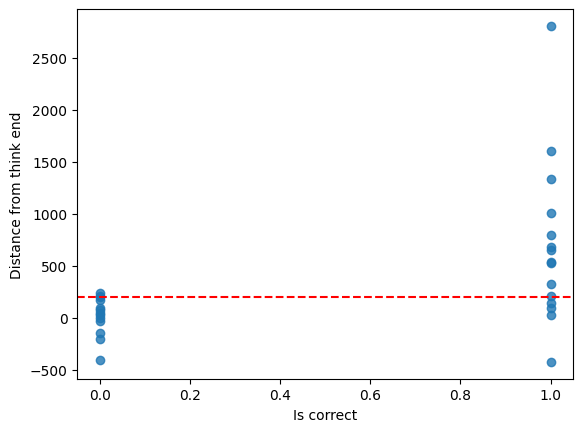

In [ ]:
# plot the relation between dists["from_think_end"] and is_correct
plt.scatter( dists["is_correct"], dists["from_think_end"], alpha=0.8)
plt.xlabel("Is correct")
plt.ylabel("Distance from think end")
plt.show()

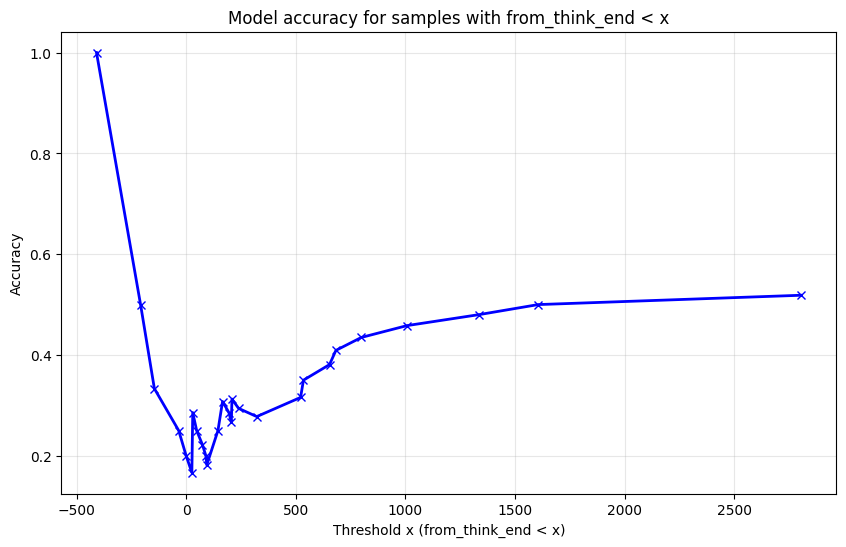

In [216]:
import numpy as np
thresholds = np.sort(dists["from_think_end"].unique())
accuracies = [dists[dists["from_think_end"] < t]["is_correct"].mean() for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, 'b-x', linewidth=2)
plt.xlabel("Threshold x (from_think_end < x)")
plt.ylabel("Accuracy")
plt.title("Model accuracy for samples with from_think_end < x")
plt.grid(True, alpha=0.3)
plt.show()

In [165]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")
stump = base_data[25]["output_token_ids"][-766:]
print((tokenizer.decode(stump)))

Alternatively, maybe the eGFP is expressed, but the construct is not functional, but the Western blot is detecting it. But the question says the signal is proportional to actin, which is a loading control, so perhaps the eGFP is expressed but not detected by the antibody. But the question says they used antibodies against the overexpressed proteins, so the eGFP should be detected if it's expressed.

Wait, the question says they used antibodies against the overexpressed proteins. So, if the eGFP is expressed, the antibody should detect it. But in the Western blot, the signal is proportional to actin, which is a loading control. So, perhaps the eGFP isn't expressed, meaning the construct isn't working.

So, why isn't the eGFP expressed? Because the construct is not in frame. So, the receptor and eGFP are not in the same reading frame, so the eGFP isn't expressed.

So, the correct answer is C.
</think>

The question involves a bicistronic vector designed to express a ligand and its recept

In [159]:
idxs = [str(i).zfill(2) for i in idxs]
idxs

['11', '13', '16', '17', '18', '20', '21', '23', '26', '27']

In [168]:
len(base_data)

100

In [ ]:
from utils.prompt_utils import get_cot_prompt

def make_prompt(base_data_dict: dict, tokenizer: AutoTokenizer):
    question = base_data_dict["question"]
    option_choices = base_data_dict["all_answers"]
    letter_choices = base_data_dict["all_letters"]
    formatted_question = f"{question}\n\nChoices:\n" + '\n'.join(f"{letter}) {option}"  
        for letter, option in zip(letter_choices, option_choices)
    )
    prompt_str = get_cot_prompt(tokenizer, formatted_question, multiple_choice=True)
    return prompt_str

def make_dataset_for_idxs(idxs: list[str | int], base_data: list[dict], file_template: str = "data/streamlit/deepseek_llama_8b/gpqa/{idx}.csv"):
    """
    Make a dataset for a list of indices.
    """
    pass

In [181]:
ogp = base_data[0]["output_text"]
newgp = load_data("00")["prefix"][20]
assert ogp.startswith(newgp)

### Forking Path Data

In [140]:
forking_file_template = "gpqa/{idx}.json"
idx = "00"
with open(forking_file_template.format(idx=idx), "r") as f:
    forking_data = json.load(f)

forking_data[0].keys()

dict_keys(['raw_answer', 'clean_answer', 'dataset_type', 'question', 'all_answers', 'all_letters', 't', 'output_text', 'post_stump_output_text', 'finish_reason', 'output_length', 'cumulative_logprob', 'norm_cumulative_logprob'])

In [144]:
def convert_forking_data_to_df(forking_paths_data):
    # compress all rollouts -> counts of outcomes
    df = pd.DataFrame(forking_paths_data)
    if 'clean_answer' not in df.columns.values:
        raise ValueError("Missing answer column.")

    outcome_df = df.groupby(['t', 'clean_answer'])['norm_cumulative_logprob'].count().reset_index().rename(
        columns={'norm_cumulative_logprob': 'num_rollouts', 'clean_answer': 'outcome'}
    )
    sum_rollouts = outcome_df.groupby('t')['num_rollouts'].sum().values[0]
    outcome_df['outcome_probability'] = outcome_df['num_rollouts'] / sum_rollouts

    # add example rollout for each timestep/final outcome
    stumps = []
    sample_continuations = []
    for i, row in outcome_df.iterrows():
        t = row.t
        outcome = row.outcome

        random_sample = df[(df['t'] == t) & (df['clean_answer'] == outcome)].sample(1)
        full_output_text = random_sample['output_text'].values[0]
        continued_text = random_sample['post_stump_output_text'].values[0]
        stump = full_output_text[:full_output_text.find(continued_text)]

        stumps.append(stump)
        sample_continuations.append(continued_text)
    outcome_df['prefix'] = stumps
    outcome_df['sample_rollout'] = sample_continuations
    return outcome_df

forking_df = convert_forking_data_to_df(forking_data)

forking_df[forking_df['outcome'] == "B"].tail()

,t,outcome,num_rollouts,outcome_probability,prefix,sample_rollout
539,4744,B,2,0.10,"Okay, so I've got this question about Klinefel...","Wait, but the question is about the mechanism ..."
541,4760,B,2,0.10,"Okay, so I've got this question about Klinefel...",So the reason is that the extra X is inactiva...
543,4780,B,2,0.10,"Okay, so I've got this question about Klinefel...","Alternatively, maybe the correct answer is B. ..."
545,4811,B,3,0.15,"Okay, so I've got this question about Klinefel...","But that's more about genetics, not the mecha..."
548,4833,B,1,0.05,"Okay, so I've got this question about Klinefel...","Because if the spindle doesn't attach, the X ..."


In [145]:
forking_df.keys()

Index(['t', 'outcome', 'num_rollouts', 'outcome_probability', 'prefix',
       'sample_rollout'],
      dtype='object')